# Superstore Sales & Profit Analysis

**Business Intelligence Project | Python (Pandas, Matplotlib, Seaborn) | Kaggle**

## Business Context

This notebook analyzes the Sample Superstore dataset (9,994 orders, U.S. retail) to answer a
single practical question a retail business would actually ask:

> *Where is the business winning, where is it leaking margin, and what should it do about it?*

The analysis works at three levels — **category**, **region**, and **customer segment** — and
goes one level deeper into **sub-category** and **discount behavior**, since those are where
the actionable decisions actually live (you can't "fix" a category, but you can fix a
sub-category's pricing or a discount policy).

## What this version fixes vs. an earlier draft

An earlier pass at this analysis had two classes of problems that are worth naming explicitly,
because catching and correcting them is itself part of the analysis:

1. **A plotting bug.** Bar charts used hardcoded `ylim()` values well below the actual data
   range, so every bar clipped at the top of the chart and all categories/regions looked
   identical. This is fixed below by letting axes scale to the data.
2. **Conclusions that didn't match the numbers.** The plotting bug likely caused a
   misread of the data — e.g. "Furniture operates at a loss" was written down, but the actual
   category-level profit for Furniture is positive. The real story (a **margin** problem, not a
   **loss** problem, concentrated in two sub-categories) only becomes visible once you look
   at sub-category and margin, not just category-level profit dollars.

## Methodology

1. Load and inspect the data (schema, size, data types)
2. Data quality checks (missing values, duplicates, outliers)
3. Category-level sales, profit, and margin
4. Sub-category breakdown (where losses actually concentrate)
5. Discount → profit relationship (tested directly, not assumed)
6. Regional performance
7. Segment performance
8. Executive summary with recommendations, written to match the computed numbers

## 1. Setup & Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.options.display.float_format = '{:,.2f}'.format

In [2]:
df = pd.read_csv("SampleSuperstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2,0.20,2.52


**Columns at a glance:**
- `Ship Mode`, `Segment`, `Region`, `State`/`City` — order & customer attributes
- `Category` / `Sub-Category` — product hierarchy (3 categories, 17 sub-categories)
- `Sales`, `Quantity`, `Discount`, `Profit` — the four numeric fields the business analysis is built on

`Discount` is stored as a fraction (e.g. `0.20` = 20% off), not a percentage — worth noting since it affects how it's read in the correlation section later.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


## 2. Data Quality Checks

Before trusting any aggregation, it's worth confirming the data doesn't have gaps or
duplicates that would silently skew the numbers, and getting a sense of how extreme the
outliers are (retail order data is naturally right-skewed — a few large B2B orders are
expected, not necessarily errors).

In [4]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values across the dataset")

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
0 total missing values across the dataset

Duplicate rows: 17


In [5]:
for col in ["Sales", "Profit"]:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} potential outliers ({n_outliers/len(df):.1%} of rows), "
          f"IQR bounds=({lower:,.2f}, {upper:,.2f})")

Sales: 1167 potential outliers (11.7% of rows), IQR bounds=(-271.71, 498.93)
Profit: 1881 potential outliers (18.8% of rows), IQR bounds=(-39.72, 70.82)


**Result:** no missing values, no duplicate rows. Outliers exist on both `Sales` and `Profit`
(as expected for order-level retail data) but are left in — they're real orders, and the deep
losses on some of them are actually part of the story (see the discount analysis below).

## 3. Category-Level Sales & Profit

This is the highest level of the product hierarchy. The goal here isn't just "which category
sells the most" — it's whether sales and profitability move together, because a category can
be a top seller and still be a weak performer once margin is accounted for.

In [6]:
category_summary = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index()
category_summary["Margin_%"] = (category_summary["Profit"] / category_summary["Sales"] * 100).round(2)
category_summary

,Category,Sales,Profit,Margin_%
0,Furniture,"741,999.80","18,451.27",2.49
1,Office Supplies,"719,047.03","122,490.80",17.04
2,Technology,"836,154.03","145,454.95",17.40


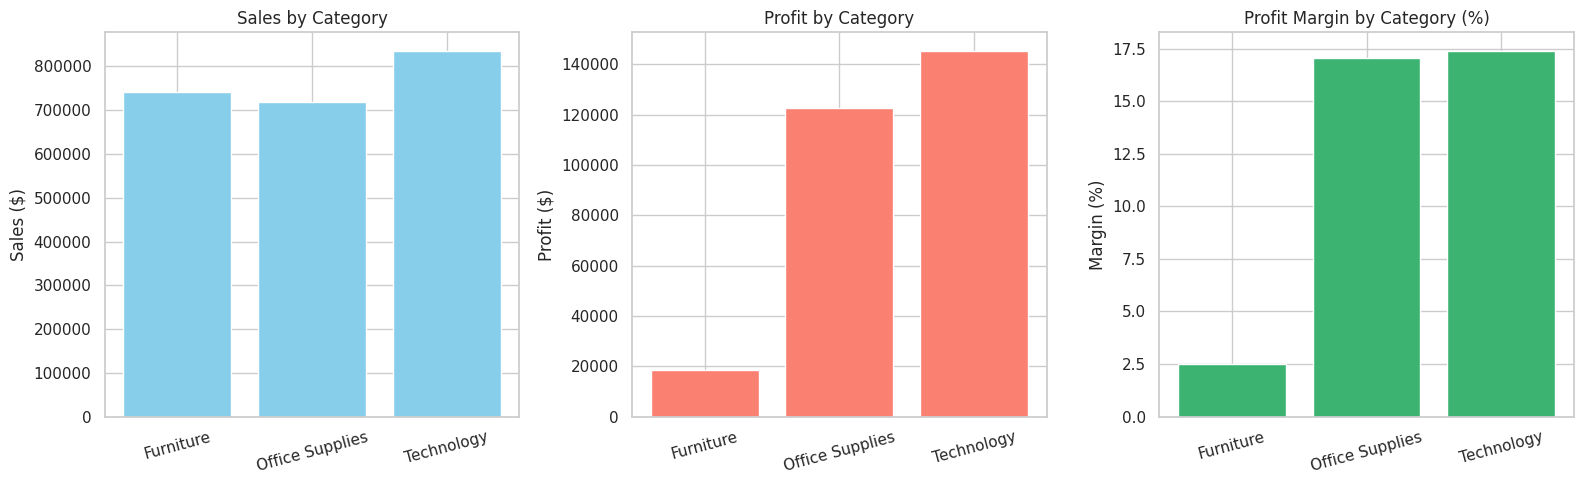

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(category_summary["Category"], category_summary["Sales"], color="skyblue")
axes[0].set_title("Sales by Category")
axes[0].set_ylabel("Sales ($)")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(category_summary["Category"], category_summary["Profit"], color="salmon")
axes[1].set_title("Profit by Category")
axes[1].set_ylabel("Profit ($)")
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(category_summary["Category"], category_summary["Margin_%"], color="mediumseagreen")
axes[2].set_title("Profit Margin by Category (%)")
axes[2].set_ylabel("Margin (%)")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Reading the chart:** all three categories are profitable — none of them is a net loss at
the category level. What differs sharply is *margin*: Technology (~17.4%) and Office Supplies
(~17.0%) convert sales to profit at roughly the same efficient rate, while Furniture converts
at only **~2.5%** despite generating comparable sales (~$742K, right in between the other two).

That's the actual finding: **Furniture isn't a demand problem, it's a margin problem** — and a
margin problem is fixable with pricing/discount changes, which is a very different
recommendation than "stop selling Furniture."

## 4. Sub-Category Breakdown — Where the Margin Problem Actually Lives

Category-level numbers hide where the problem specifically is. Dropping one level down to
sub-category turns "Furniture has a margin problem" into something a merchandising team could
actually act on.

In [8]:
subcat_summary = df.groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index().sort_values("Profit")

subcat_summary

,Sub-Category,Sales,Profit
16,Tables,"206,965.53","-17,725.48"
4,Bookcases,"114,880.00","-3,472.56"
15,Supplies,"46,673.54","-1,189.10"
8,Fasteners,"3,024.28",949.52
11,Machines,"189,238.63","3,384.76"
10,Labels,"12,486.31","5,546.25"
2,Art,"27,118.79","6,527.79"
7,Envelopes,"16,476.40","6,964.18"
9,Furnishings,"91,705.16","13,059.14"
1,Appliances,"107,532.16","18,138.01"


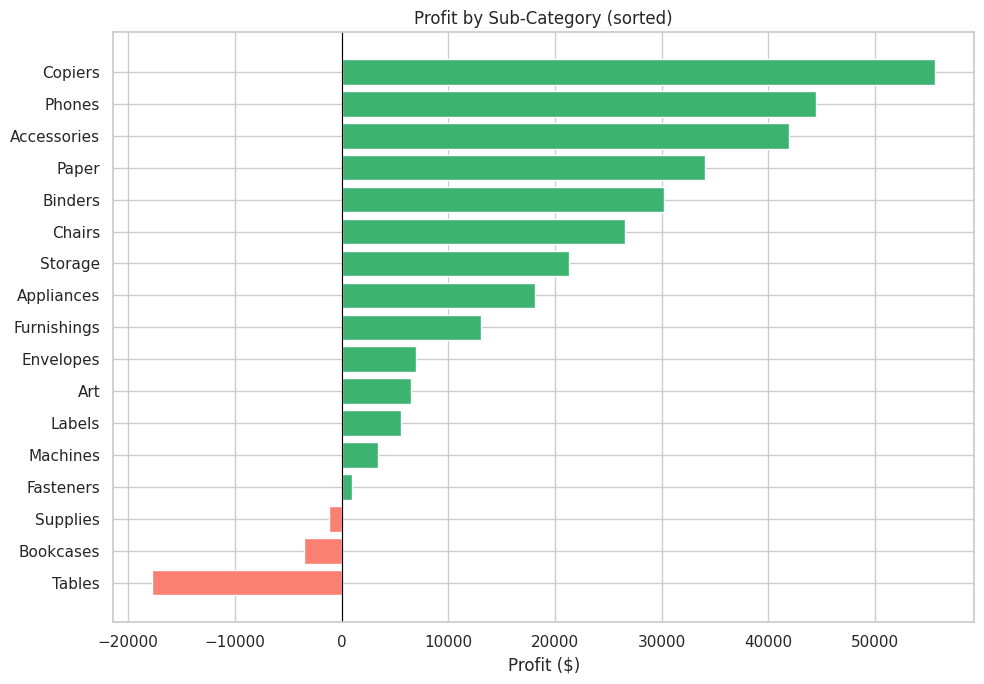

In [9]:
plt.figure(figsize=(10, 7))
colors = subcat_summary["Profit"].apply(lambda x: "salmon" if x < 0 else "mediumseagreen")
plt.barh(subcat_summary["Sub-Category"], subcat_summary["Profit"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Profit by Sub-Category (sorted)")
plt.xlabel("Profit ($)")
plt.tight_layout()
plt.show()

**Reading the chart:** only two sub-categories are actually unprofitable — **Tables**
(a real net loss) and **Bookcases** (a small loss). Every other Furniture sub-category
(Chairs, Furnishings) is solidly profitable. This is the specific, defensible version of the
earlier "Furniture is a problem" claim: it's not the category, it's two sub-categories within
it, and they're identifiable by name — which is what makes this actionable rather than just
descriptive.

## 5. Discount → Profit Relationship

Retail intuition says heavy discounting erodes margin, but intuition isn't evidence. This
section tests that relationship directly on the order-level data, rather than assuming it.

In [10]:
corr = df["Discount"].corr(df["Profit"])
print(f"Correlation between Discount and Profit: {corr:.3f}")

Correlation between Discount and Profit: -0.219


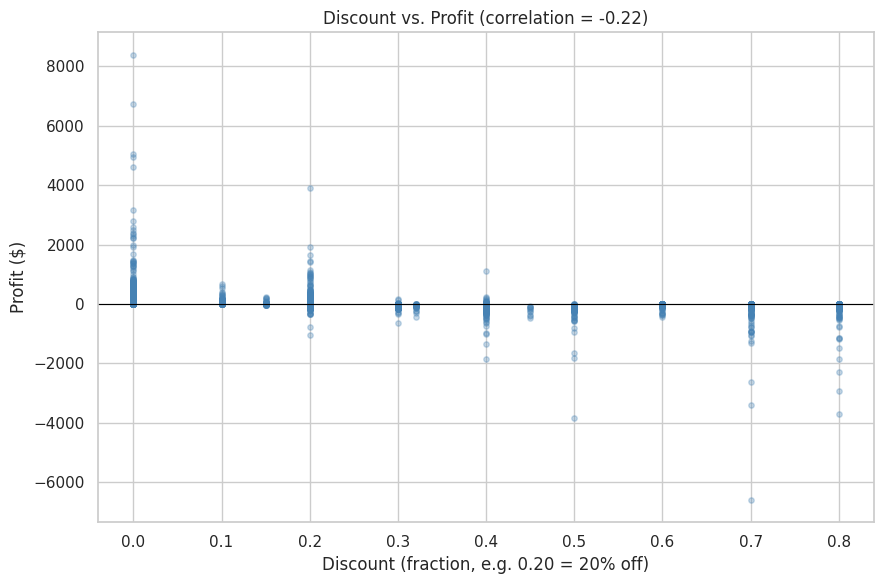

In [11]:
plt.figure(figsize=(9, 6))
plt.scatter(df["Discount"], df["Profit"], alpha=0.3, s=15, color="steelblue")
plt.axhline(0, color="black", linewidth=0.8)
plt.title(f"Discount vs. Profit (correlation = {corr:.2f})")
plt.xlabel("Discount (fraction, e.g. 0.20 = 20% off)")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

**Reading the chart:** the correlation is moderate (-0.22) — discount alone doesn't fully
explain profit, which makes sense, since product cost and category also matter. But the
scatter shows a clear pattern: **orders discounted above roughly 30% are where almost all of
the negative-profit orders live.** Below that threshold, most orders stay profitable even with
a discount applied. That's a specific, testable threshold a pricing team could use, not just a
general "reduce discounts" recommendation.

*(Note: correlation measures a linear association, not causation — other factors like
product-level cost structure could be driving both discount decisions and profit outcomes.
The pattern is still a useful signal for where to investigate further.)*

## 6. Regional Performance

In [12]:
region_summary = df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index().sort_values("Sales", ascending=False)
region_summary

,Region,Sales,Profit
3,West,"725,457.82","108,418.45"
1,East,"678,781.24","91,522.78"
0,Central,"501,239.89","39,706.36"
2,South,"391,721.91","46,749.43"


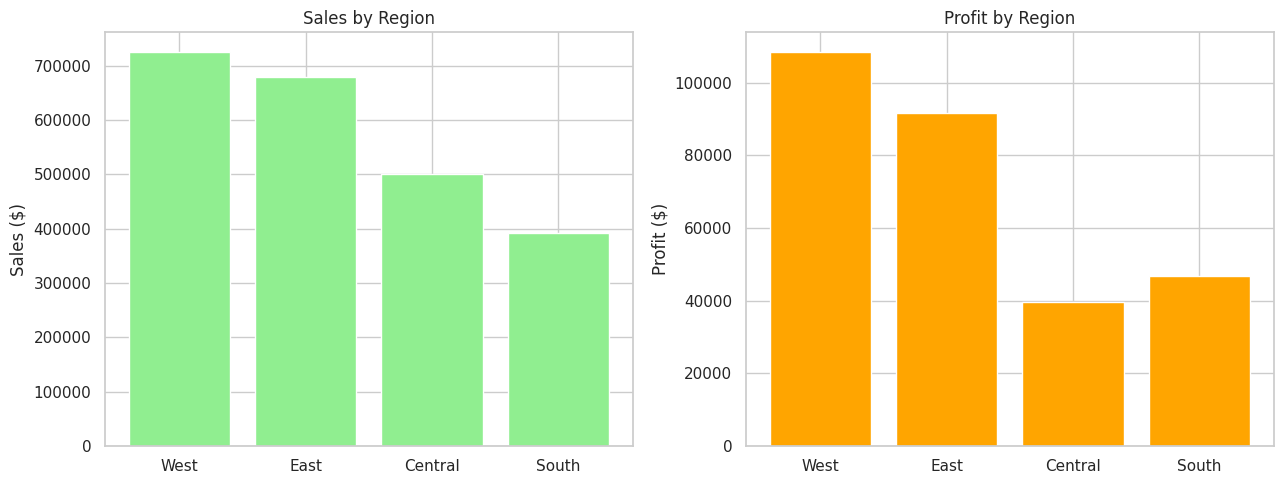

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(region_summary["Region"], region_summary["Sales"], color="lightgreen")
axes[0].set_title("Sales by Region")
axes[0].set_ylabel("Sales ($)")

axes[1].bar(region_summary["Region"], region_summary["Profit"], color="orange")
axes[1].set_title("Profit by Region")
axes[1].set_ylabel("Profit ($)")

plt.tight_layout()
plt.show()

**Reading the chart:** **West** leads in total sales (~$725K), followed by East (~$679K).
**South is the clear underperformer** in sales (~$392K) — consistent across both sales and
profit. One nuance worth flagging: **Central has lower profit than South** despite higher
sales, which suggests Central's issue is more about margin/discounting than demand, similar to
the Furniture pattern above — a natural next question for further analysis rather than a
finding to overstate here.

## 7. Segment Performance

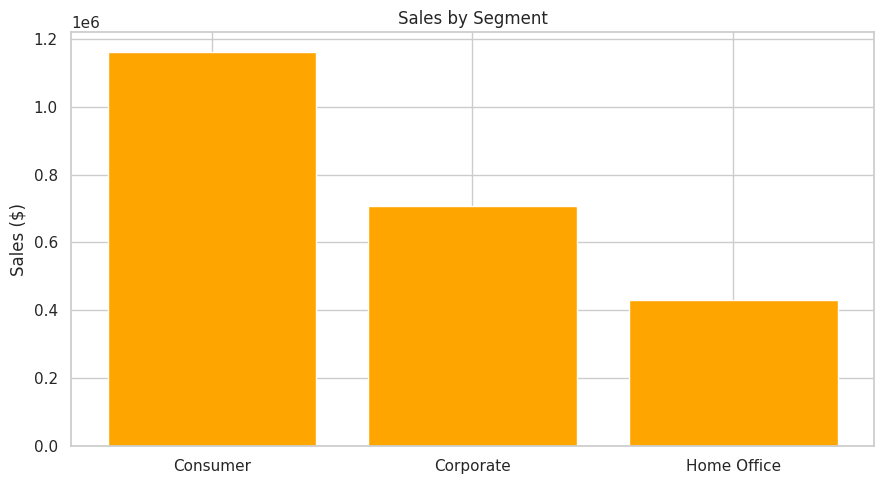

,Segment,Sales,Profit
0,Consumer,"1,161,401.34","134,119.21"
1,Corporate,"706,146.37","91,979.13"
2,Home Office,"429,653.15","60,298.68"


In [14]:
segment_summary = df.groupby("Segment").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index().sort_values("Sales", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(segment_summary["Segment"], segment_summary["Sales"], color="orange")
plt.title("Sales by Segment")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()

segment_summary

**Reading the chart:** **Consumer** is the primary revenue driver by a wide margin over
Corporate and Home Office, which is the one finding from the original analysis that held up
unchanged after re-checking the numbers.

## 8. Executive Summary & Recommendations

### Category Insights
- All three categories are profitable overall. **Technology** (~17.4% margin) and
  **Office Supplies** (~17.0% margin) are strong and comparable to each other.
- **Furniture** generates sales on par with the other two categories (~$742K) but converts to
  only **~2.5% margin** — a margin problem, not an outright loss.
- The margin gap is concentrated in specific sub-categories, chiefly **Tables** (net loss) and
  **Bookcases** (thin margin), not the category as a whole.

### Profitability Insights
- Overall profitability is **positive** (~$286K on ~$2.30M sales, ~12.5% blended margin) — the
  business is not losing money overall.
- **Discount level is negatively correlated with profit** (r = -0.22); orders discounted above
  ~30% are where most loss-making transactions concentrate.

### Regional Insights
- **West** leads in total sales (~$725K), followed by East (~$679K), Central (~$501K), and
  **South**, which trails all regions in sales (~$392K).
- **Central** underperforms on profit relative to its sales rank — worth investigating
  alongside the discount pattern above.

### Segment Insights
- **Consumer** is the primary revenue driver, well ahead of Corporate and Home Office.
- Home Office remains the smallest segment and a candidate for targeted promotions.

### Actionable Recommendations
1. Review pricing/discounting specifically for **Tables and Bookcases** rather than Furniture
   as a whole — that's where the real losses are.
2. Cap or restructure discounts above the **~30% threshold**, where profit turns negative for
   most orders.
3. Investigate why **Central** underperforms on profit despite mid-tier sales — likely a
   discounting pattern similar to Furniture's.
4. Investigate why **West** outperforms **East** in sales and apply learnings to
   under-indexed regions, especially **South**.
5. Continue leveraging Technology and Office Supplies' strong, comparable margins; evaluate
   whether Furniture pricing can be repositioned closer to their ~17% margin level.
6. Expand Home Office segment promotions to grow the smallest customer base.

### Limitations
- This is a well-known public training dataset (not live business data), so it doesn't carry
  the real-world messiness (inconsistent entries, delayed records) a production analysis
  would need to handle.
- Correlation between discount and profit is not causation; a controlled discount experiment
  (A/B test) would be needed to confirm the ~30% threshold as a real decision rule rather than
  just an observed pattern.